In [15]:
# Import libraries
import yfinance as yf
import numpy as np
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
import seaborn as sns
import torch.optim as optim
import pandas as pd

**DATA GENERATION**

In [2]:
tickers = ["AAPL","MSFT","NVDA","AMD","GOOG", "META", "AMZN", "TSLA", "INTC", "IBM"]
data = yf.download(tickers, start="2018-01-01")['Close']
data = data.dropna() # drop rows with missing values
# print(data.head())

# Training / Test split
x_test = yf.download(tickers, start="2023-01-01")['Close'] # test on future data
y_test = x_test.pct_change().dropna() # predict next-day returns

x_train = data[data.index < "2023-01-01"] # train on past data
y_train = x_train.pct_change().dropna()

# Test prints
print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)
print("Training returns shape:", y_train.shape)
print("Test returns shape:", y_test.shape)

print("Training data head:")
print(x_train.head())
print("Training returns head:")
print(y_train.head())

[*********************100%***********************]  10 of 10 completed
[*********************100%***********************]  10 of 10 completed

Training data shape: (1259, 10)
Test data shape: (820, 10)
Training returns shape: (1258, 10)
Test returns shape: (819, 10)
Training data head:
Ticker           AAPL    AMD       AMZN       GOOG         IBM       INTC  \
Date                                                                        
2018-01-02  40.304176  10.98  59.450500  52.816376  103.412834  39.330387   
2018-01-03  40.297153  11.55  60.209999  53.683266  106.255402  37.995590   
2018-01-04  40.484333  12.12  60.479500  53.877666  108.407463  37.298809   
2018-01-05  40.945255  11.88  61.457001  54.662720  108.937119  37.559059   
2018-01-08  40.793179  12.28  62.343498  54.896305  109.594124  37.559059   

Ticker            META       MSFT      NVDA       TSLA  
Date                                                    
2018-01-02  180.007416  78.870361  4.928267  21.368668  
2018-01-03  183.232101  79.237404  5.252614  21.150000  
2018-01-04  182.894745  79.934807  5.280303  20.974667  
2018-01-05  185.395111  80.9258

In [3]:
x_test_tensor = torch.tensor(x_test.values[:-1], dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

x_train_tensor = torch.tensor(x_train.values[:-1], dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)

# Test prints
print("Aligned training data shape:", x_train_tensor.shape)
print("Aligned test data shape:", x_test_tensor.shape)
print("Aligned training returns shape:", y_train_tensor.shape)
print("Aligned test returns shape:", y_test_tensor.shape)

print("Aligned training data head:")
print(x_train_tensor[:5])
print("Aligned training returns head:")
print(y_train_tensor[:5])

Aligned training data shape: torch.Size([1258, 10])
Aligned test data shape: torch.Size([819, 10])
Aligned training returns shape: torch.Size([1258, 10])
Aligned test returns shape: torch.Size([819, 10])
Aligned training data head:
tensor([[ 40.3042,  10.9800,  59.4505,  52.8164, 103.4128,  39.3304, 180.0074,
          78.8704,   4.9283,  21.3687],
        [ 40.2972,  11.5500,  60.2100,  53.6833, 106.2554,  37.9956, 183.2321,
          79.2374,   5.2526,  21.1500],
        [ 40.4843,  12.1200,  60.4795,  53.8777, 108.4075,  37.2988, 182.8947,
          79.9348,   5.2803,  20.9747],
        [ 40.9453,  11.8800,  61.4570,  54.6627, 108.9371,  37.5591, 185.3951,
          80.9258,   5.3250,  21.1053],
        [ 40.7932,  12.2800,  62.3435,  54.8963, 109.5941,  37.5591, 186.8140,
          81.0084,   5.4882,  22.4273]])
Aligned training returns head:
tensor([[-0.0002,  0.0519,  0.0128,  0.0164,  0.0275, -0.0339,  0.0179,  0.0047,
          0.0658, -0.0102],
        [ 0.0046,  0.0494,  0.00

**GRAPH CONSTRUCTION**

In [4]:
def stock_graph(y):
    # correlation matrix as adjacency (as a start)
    corr = np.corrcoef(y.T)
    np.fill_diagonal(corr, 0)  # remove self-loops
    return corr

def normalize_graph(G):
    # optional: divide by largest eigenvalue
    eigs = np.linalg.eigvals(G)
    return G / np.max(np.abs(eigs))

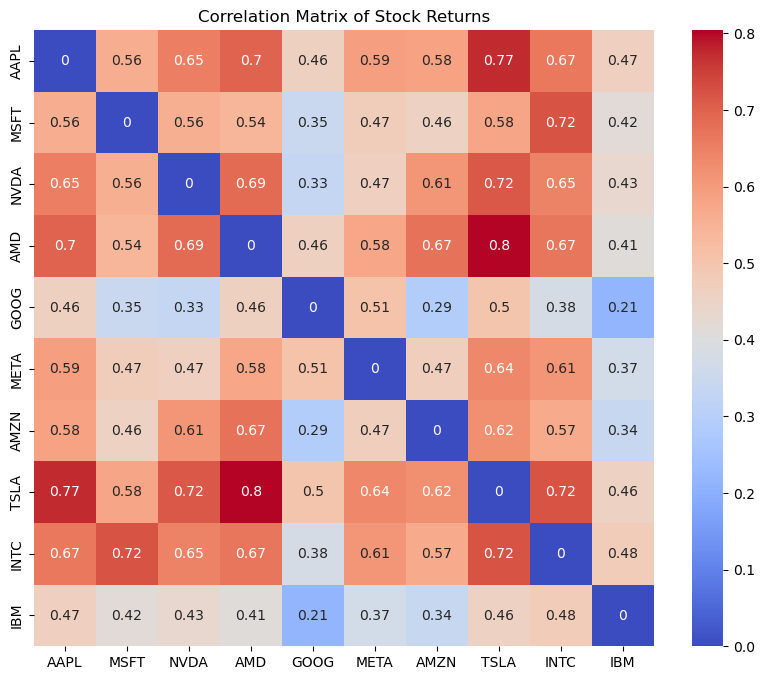

In [5]:
# Plot the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(stock_graph(y_train), annot=True, cmap='coolwarm', xticklabels=tickers, yticklabels=tickers)
plt.title('Correlation Matrix of Stock Returns')
plt.show()

**GRAPH FILTER**

In [6]:
def filter_function(h, S, x):
    """
    Preforms graph filtering on the input signal x using the filter coefficients h and the graph Laplacian S.

    ARGS:
    h: filter coefficients (h_1, h_2, ..., h_K)
    S: graph Laplacian
    x: input signal size (B,N)

    RETURNS:
    y: output signal after applying the graph filter
    """

    K = h.shape[0] # number of filter coefficients h_1, h_2, ..., h_K
    B = x.shape[0] # batch size (number of samples processed in parallel)
    N = x.shape[1] # number of nodes (= number of stocks in our case)

    x = x.reshape([B, 1, N]) 
    S = S.reshape([1, N, N])
    z = x

    for k in range(1, K):

        # diffusion step, S^k*x
        x = torch.matmul(x, S)
        xS = x.reshape([B, 1, N]) 

        # concatenate the S^k*x in the tensor z
        z = torch.cat((z, xS), dim=1) 

    # multiply z and h in the concatenation dimension
    y = torch.matmul(z.permute(0, 2, 1).reshape([B, N, K]), h)

    return y

class graph_filter(nn.Module):
    """
    Graph filter layer that applies a learnable graph filter to the input signal.
    """
    def __init__(self, corr, k):
        
        # Initialize parent
        super().__init__()
        
        # Save filter hyperparameters
        self.graph = torch.tensor(corr)
        self.n = corr.shape[0]
        self.k = k
        
        # Define and initialize learnable weights
        self.weight = nn.Parameter(torch.randn(self.k))
        self.reset_parameters()
        
    def reset_parameters(self):
        stdv = 1. / math.sqrt(self.k)
        self.weight.data.uniform_(-stdv, stdv)

    def forward(self, x):
        return filter_function(self.weight, self.graph, x)

**TESTING**

In [7]:
def train_model(model, x_train, y_train, lr=0.01, epochs=300):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    losses = []
    for epoch in range(epochs):
        optimizer.zero_grad()
        y_pred = model(x_train)
        loss = criterion(y_pred, y_train)
        losses.append(loss.item())
        loss.backward()
        optimizer.step()
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}")
        if loss.item() < 1e-6:
            print(f"Early stopping at epoch {epoch+1} with loss {loss.item():.6f}")
            break
    return model, losses

In [8]:
class graph_perceptron(nn.Module):
    def __init__(self, gso, k, sigma):
        super().__init__()
        self.gso = torch.tensor(gso)
        self.n = gso.shape[0]
        self.k = k
        self.sigma = sigma
        self.weight = nn.Parameter(torch.randn(self.k))
        self.reset_parameters()
        
    def reset_parameters(self):
        stdv = 1. / math.sqrt(self.k)
        self.weight.data.uniform_(-stdv, stdv)

    def forward(self, x):
        y = filter_function(self.weight, self.gso, x)
        y = self.sigma(y)
        return y    

In [9]:
class MLGNN(nn.Module):
    def __init__(self, gso, l, k, sigma):
        super().__init__()
        layers = []
        for layer in range(l):
            layers.append(graph_perceptron(gso, k[layer], sigma))
        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        y = self.layers(x)
        return y

/var/folders/4c/9txylvm93f19c2g9h_f3cg680000gn/T/ipykernel_55820/281005117.py:46: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.graph = torch.tensor(corr)
/var/folders/4c/9txylvm93f19c2g9h_f3cg680000gn/T/ipykernel_55820/3123335899.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.gso = torch.tensor(gso)


Training Graph Filter...
Epoch 10/300, Loss: 720.926331
Epoch 20/300, Loss: 373.250092
Epoch 30/300, Loss: 153.510437
Epoch 40/300, Loss: 47.930489
Epoch 50/300, Loss: 9.214951
Epoch 60/300, Loss: 0.508040
Epoch 70/300, Loss: 0.314074
Epoch 80/300, Loss: 0.608889
Epoch 90/300, Loss: 0.403033
Epoch 100/300, Loss: 0.180337
Epoch 110/300, Loss: 0.105363
Epoch 120/300, Loss: 0.100776
Epoch 130/300, Loss: 0.102717
Epoch 140/300, Loss: 0.100781
Epoch 150/300, Loss: 0.099098
Epoch 160/300, Loss: 0.098561
Epoch 170/300, Loss: 0.098296
Epoch 180/300, Loss: 0.097968
Epoch 190/300, Loss: 0.097626
Epoch 200/300, Loss: 0.097293
Epoch 210/300, Loss: 0.096957
Epoch 220/300, Loss: 0.096613
Epoch 230/300, Loss: 0.096260
Epoch 240/300, Loss: 0.095901
Epoch 250/300, Loss: 0.095534
Epoch 260/300, Loss: 0.095160
Epoch 270/300, Loss: 0.094780
Epoch 280/300, Loss: 0.094393
Epoch 290/300, Loss: 0.094000
Epoch 300/300, Loss: 0.093600


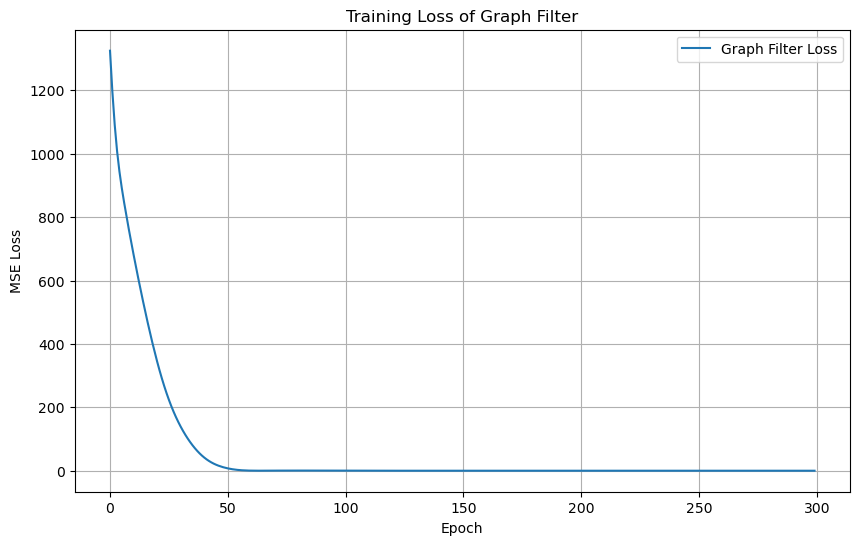

Training Graph Perceptron...
Epoch 10/300, Loss: 17907.320312
Epoch 20/300, Loss: 10339.750000
Epoch 30/300, Loss: 5271.708008
Epoch 40/300, Loss: 2305.330566
Epoch 50/300, Loss: 832.418945
Epoch 60/300, Loss: 238.478973
Epoch 70/300, Loss: 56.549641
Epoch 80/300, Loss: 14.495397
Epoch 90/300, Loss: 4.723884
Epoch 100/300, Loss: 2.070060
Epoch 110/300, Loss: 1.177745
Epoch 120/300, Loss: 0.788451
Epoch 130/300, Loss: 0.578984
Epoch 140/300, Loss: 0.447095
Epoch 150/300, Loss: 0.354883
Epoch 160/300, Loss: 0.286583
Epoch 170/300, Loss: 0.234505
Epoch 180/300, Loss: 0.194213
Epoch 190/300, Loss: 0.162757
Epoch 200/300, Loss: 0.138061
Epoch 210/300, Loss: 0.118604
Epoch 220/300, Loss: 0.103185
Epoch 230/300, Loss: 0.090840
Epoch 240/300, Loss: 0.080780
Epoch 250/300, Loss: 0.072423
Epoch 260/300, Loss: 0.065353
Epoch 270/300, Loss: 0.059281
Epoch 280/300, Loss: 0.054003
Epoch 290/300, Loss: 0.049383
Epoch 300/300, Loss: 0.045321


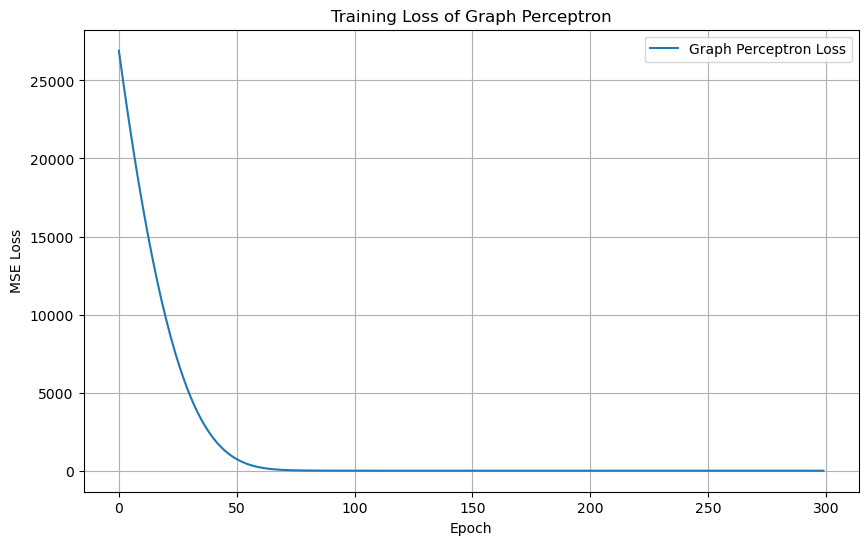

Training MLGNN...
Epoch 10/300, Loss: 0.000740
Epoch 20/300, Loss: 0.000740
Epoch 30/300, Loss: 0.000740
Epoch 40/300, Loss: 0.000740
Epoch 50/300, Loss: 0.000740
Epoch 60/300, Loss: 0.000740
Epoch 70/300, Loss: 0.000740
Epoch 80/300, Loss: 0.000740
Epoch 90/300, Loss: 0.000740
Epoch 100/300, Loss: 0.000740
Epoch 110/300, Loss: 0.000740
Epoch 120/300, Loss: 0.000740
Epoch 130/300, Loss: 0.000740
Epoch 140/300, Loss: 0.000740
Epoch 150/300, Loss: 0.000740
Epoch 160/300, Loss: 0.000740
Epoch 170/300, Loss: 0.000740
Epoch 180/300, Loss: 0.000740
Epoch 190/300, Loss: 0.000740
Epoch 200/300, Loss: 0.000740
Epoch 210/300, Loss: 0.000740
Epoch 220/300, Loss: 0.000740
Epoch 230/300, Loss: 0.000740
Epoch 240/300, Loss: 0.000740
Epoch 250/300, Loss: 0.000740
Epoch 260/300, Loss: 0.000740
Epoch 270/300, Loss: 0.000740
Epoch 280/300, Loss: 0.000740
Epoch 290/300, Loss: 0.000740
Epoch 300/300, Loss: 0.000740


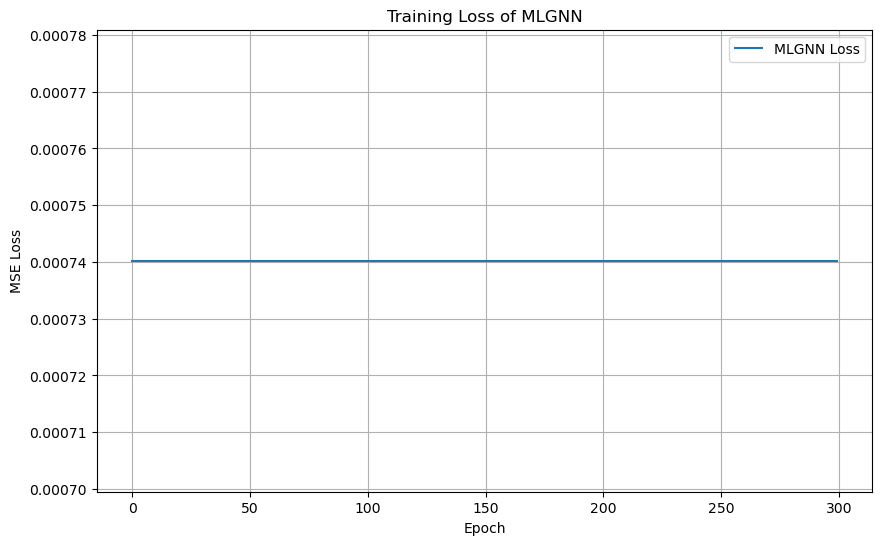

In [10]:
corr = stock_graph(y_train)
corr = normalize_graph(corr)
corr = torch.tensor(corr, dtype=torch.float32)

K = 3
gf_model = graph_filter(corr, K)
gp_model = graph_perceptron(corr, K, nn.ReLU())
mlgnn_model = MLGNN(corr, l=2, k=[3, 3], sigma=nn.ReLU())

print("Training Graph Filter...")
gf_model, gf_losses = train_model(gf_model, x_train_tensor, y_train_tensor)
# plot loss per epoch for graph filter
plt.figure(figsize=(10, 6))
plt.plot(gf_losses, label='Graph Filter Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss of Graph Filter')
plt.legend()
plt.grid()
plt.show()

print("Training Graph Perceptron...")
gp_model, gp_losses = train_model(gp_model, x_train_tensor, y_train_tensor)
# plot loss per epoch for graph perceptron
plt.figure(figsize=(10, 6))
plt.plot(gp_losses, label='Graph Perceptron Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss of Graph Perceptron')
plt.legend()
plt.grid()
plt.show()

print("Training MLGNN...")
mlgnn_model, mlgnn_losses = train_model(mlgnn_model, x_train_tensor, y_train_tensor)
# plot loss per epoch for MLGNN
plt.figure(figsize=(10, 6))
plt.plot(mlgnn_losses, label='MLGNN Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss of MLGNN')
plt.legend()
plt.grid()
plt.show()


=== Test Results ===
Graph Filter Test Loss: 0.310445
Graph Perceptron Test Loss: 0.210947
MLGNN Test Loss: 0.000679


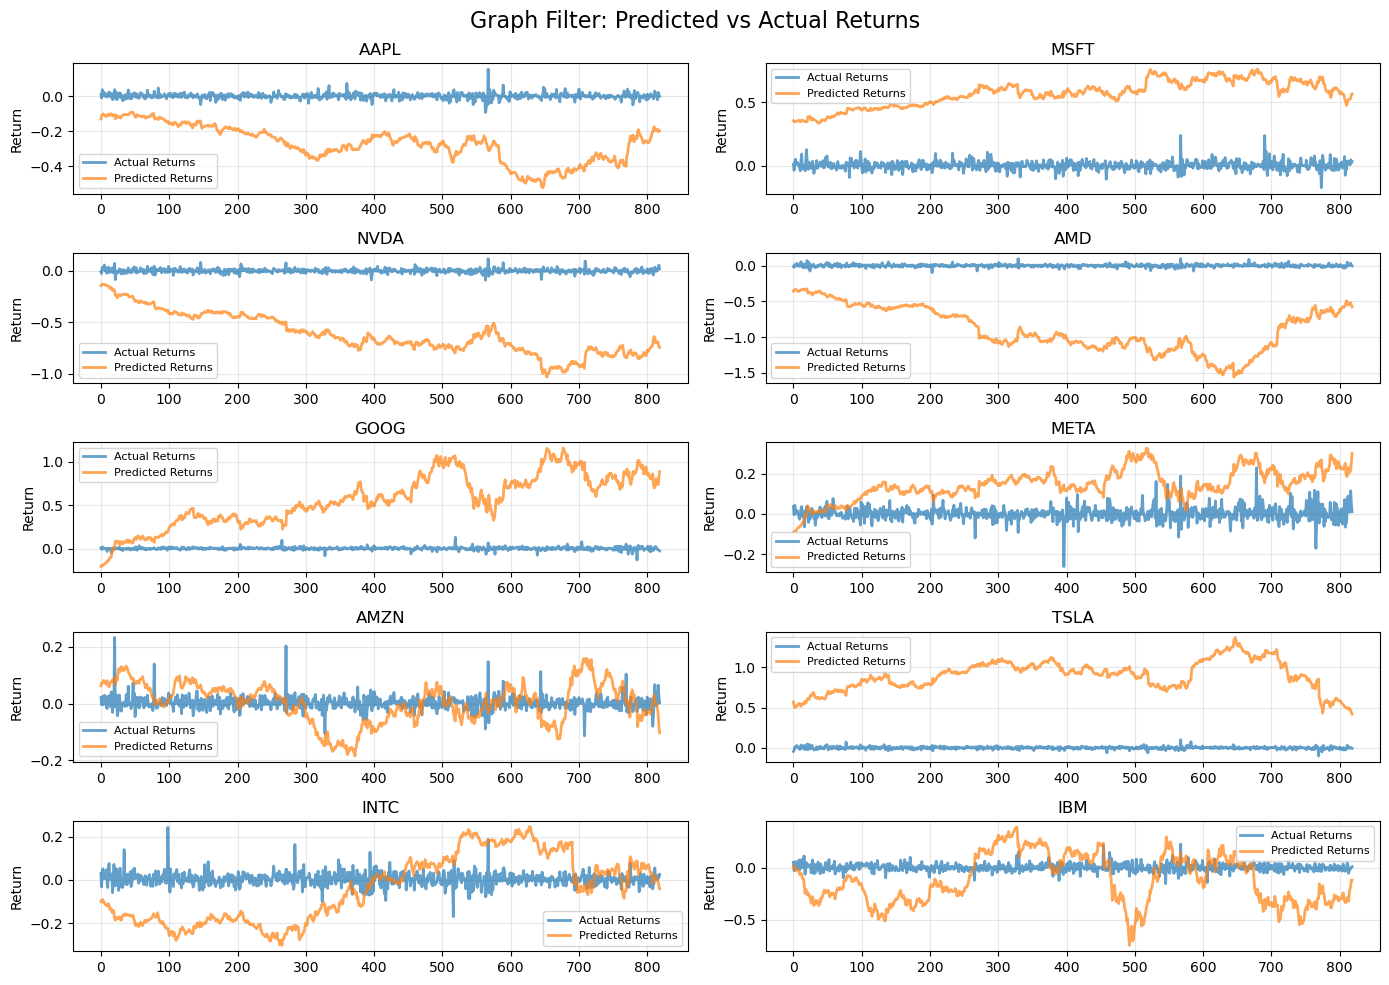

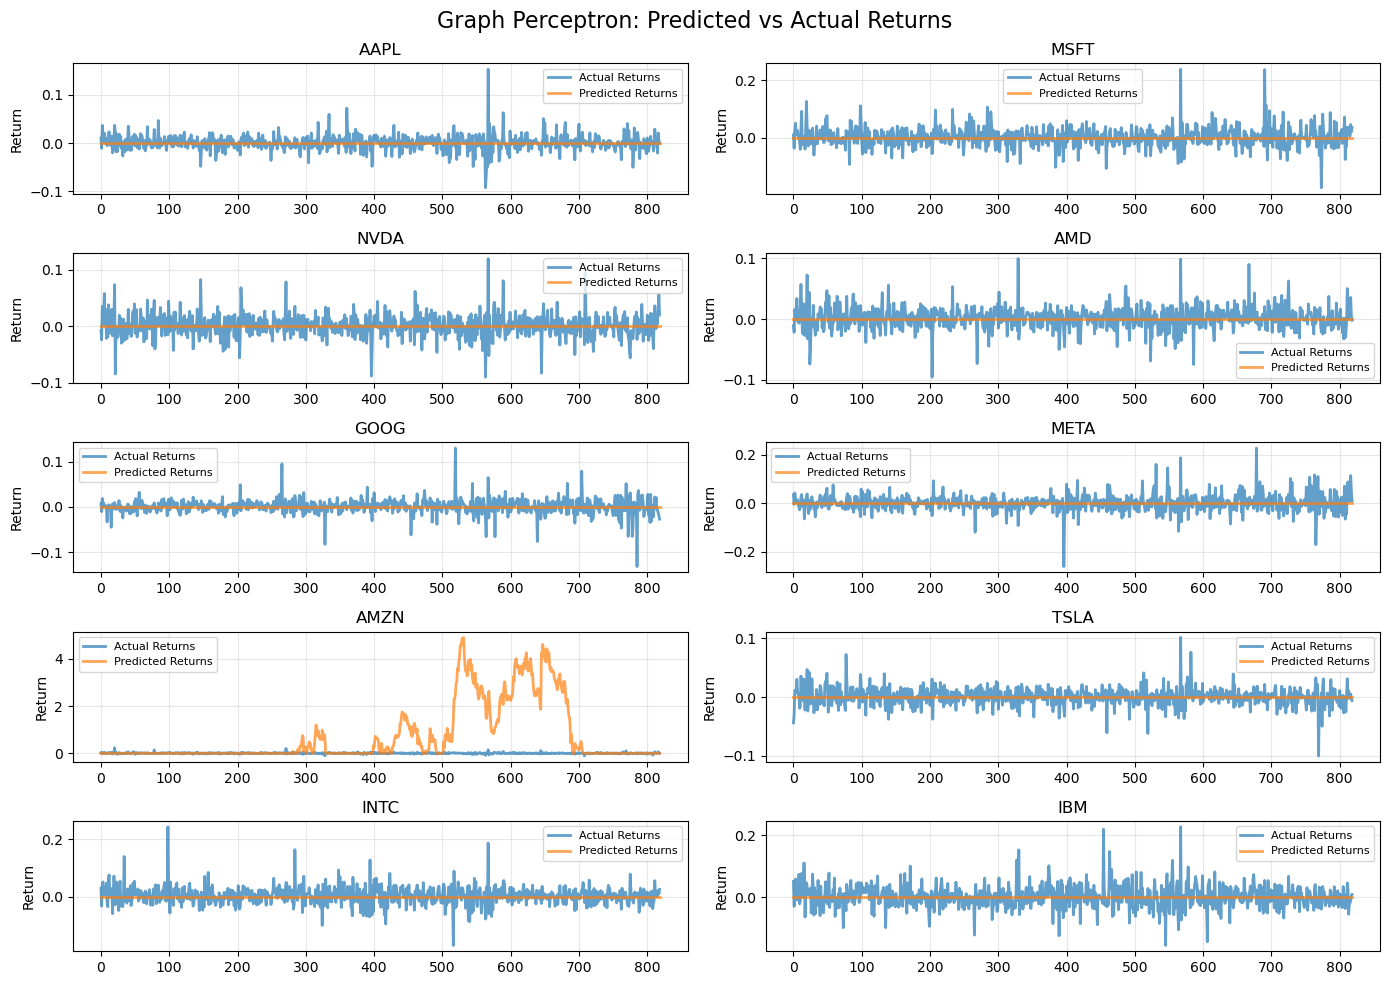

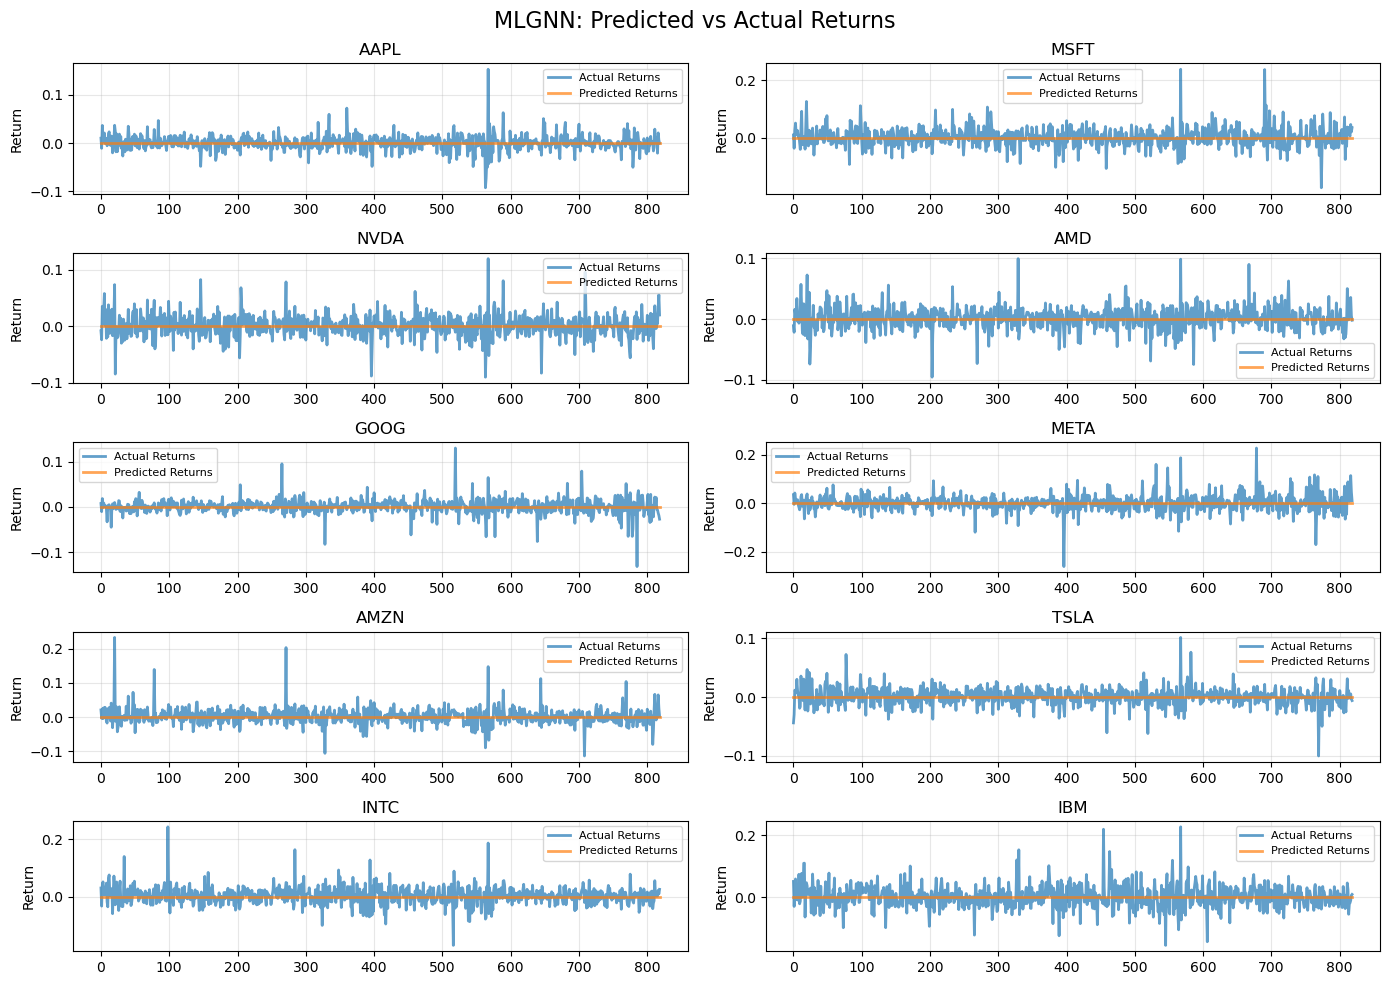

In [11]:
# Evaluate models on test data
criterion = nn.MSELoss()

# Make predictions with both models
with torch.no_grad():
    gf_pred = gf_model(x_test_tensor)
    gp_pred = gp_model(x_test_tensor)
    mlgnn_pred = mlgnn_model(x_test_tensor)
    
    # Compute test loss
    gf_test_loss = criterion(gf_pred, y_test_tensor)
    gp_test_loss = criterion(gp_pred, y_test_tensor)
    mlgnn_test_loss = criterion(mlgnn_pred, y_test_tensor)

print(f"\n=== Test Results ===")
print(f"Graph Filter Test Loss: {gf_test_loss.item():.6f}")
print(f"Graph Perceptron Test Loss: {gp_test_loss.item():.6f}")
print(f"MLGNN Test Loss: {mlgnn_test_loss.item():.6f}")

# Plot predicted vs actual returns per stock for Graph Filter
plt.figure(figsize=(14, 10))
plt.suptitle('Graph Filter: Predicted vs Actual Returns', fontsize=16)
for i, ticker in enumerate(tickers):
    plt.subplot(5, 2, i+1)
    plt.plot(y_test_tensor[:, i].numpy(), label='Actual Returns', linewidth=2, alpha=0.7)
    plt.plot(gf_pred[:, i].numpy(), label='Predicted Returns', linewidth=2, alpha=0.7)
    plt.title(f'{ticker}')
    plt.ylabel('Return')
    plt.legend(fontsize=8)
    plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot predicted vs actual returns per stock for Graph Perceptron
plt.figure(figsize=(14, 10))
plt.suptitle('Graph Perceptron: Predicted vs Actual Returns', fontsize=16)
for i, ticker in enumerate(tickers):
    plt.subplot(5, 2, i+1)
    plt.plot(y_test_tensor[:, i].numpy(), label='Actual Returns', linewidth=2, alpha=0.7)
    plt.plot(gp_pred[:, i].numpy(), label='Predicted Returns', linewidth=2, alpha=0.7)
    plt.title(f'{ticker}')
    plt.ylabel('Return')
    plt.legend(fontsize=8)
    plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot predicted vs actual returns per stock for MLGNN
plt.figure(figsize=(14, 10))
plt.suptitle('MLGNN: Predicted vs Actual Returns', fontsize=16)
for i, ticker in enumerate(tickers):
    plt.subplot(5, 2, i+1)
    plt.plot(y_test_tensor[:, i].numpy(), label='Actual Returns', linewidth=2, alpha=0.7)
    plt.plot(mlgnn_pred[:, i].numpy(), label='Predicted Returns', linewidth=2, alpha=0.7)
    plt.title(f'{ticker}')
    plt.ylabel('Return')
    plt.legend(fontsize=8)
    plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# for multi features add: past 5 days data, moving average, volatility, etc.


## Multi-feature part

This part adds a multi-feature GNN model so that we can see the plan from the presentation: past 5 days, moving-average style features, and volatility. 

In [ ]:
def build_feature_panel(close_df, lag_days=5, ma_windows=(5, 10), vol_windows=(5,)):
    """
    Build node features for each stock using only information available up to time t.
    Target is next-day return r_{t+1}.

    Returns
    -------
    X : np.ndarray of shape (B, F, N)
        B = number of samples
        F = number of engineered features
        N = number of stocks
    Y : np.ndarray of shape (B, N)
        Next-day returns for each stock
    feature_names : list[str]
        Names of feature channels in X
    valid_dates : pd.Index
        Dates corresponding to each sample
    returns_df : pd.DataFrame
        Daily returns aligned to the original close_df index
    """
    close_df = close_df.copy()
    returns_df = close_df.pct_change()

    feature_frames = []
    feature_names = []

    # 1) Lagged returns: r_t, r_{t-1}, ..., r_{t-lag_days+1}
    for lag in range(lag_days):
        feat = returns_df.shift(lag)
        feature_frames.append(feat)
        feature_names.append(f"ret_lag_{lag+1}")

    # 2) Moving-average gap features on prices
    for w in ma_windows:
        ma = close_df.rolling(w).mean()
        feat = (close_df / ma) - 1.0
        feature_frames.append(feat)
        feature_names.append(f"price_vs_ma_{w}")

    # 3) Rolling volatility of returns
    for w in vol_windows:
        feat = returns_df.rolling(w).std()
        feature_frames.append(feat)
        feature_names.append(f"vol_{w}")

    # Optional momentum feature: mean recent return
    for w in ma_windows:
        feat = returns_df.rolling(w).mean()
        feature_frames.append(feat)
        feature_names.append(f"ret_mean_{w}")

    # Next-day target
    target_df = returns_df.shift(-1)

    # Keep only dates where every feature and target exists
    valid_mask = target_df.notna().all(axis=1)
    for feat in feature_frames:
        valid_mask &= feat.notna().all(axis=1)

    valid_dates = close_df.index[valid_mask]

    X = np.stack([feat.loc[valid_dates].values for feat in feature_frames], axis=1)  # (B,F,N)
    Y = target_df.loc[valid_dates].values  # (B,N)

    return X, Y, feature_names, valid_dates, returns_df


def train_test_split_panel(close_df, split_date="2023-01-01", lag_days=5, ma_windows=(5, 10), vol_windows=(5,)):
    X, Y, feature_names, valid_dates, returns_df = build_feature_panel(
        close_df, lag_days=lag_days, ma_windows=ma_windows, vol_windows=vol_windows
    )

    train_mask = valid_dates < pd.Timestamp(split_date)
    test_mask = valid_dates >= pd.Timestamp(split_date)

    X_train = X[train_mask]
    Y_train = Y[train_mask]
    X_test = X[test_mask]
    Y_test = Y[test_mask]

    train_dates = valid_dates[train_mask]
    test_dates = valid_dates[test_mask]

    return X_train, Y_train, X_test, Y_test, feature_names, train_dates, test_dates, returns_df


def standardize_panel(X_train, X_test, eps=1e-8):
    """
    Standardize each feature channel using train-set statistics only.
    X shapes: (B,F,N)
    """
    mean = X_train.mean(axis=(0, 2), keepdims=True)
    std = X_train.std(axis=(0, 2), keepdims=True) + eps

    X_train_std = (X_train - mean) / std
    X_test_std = (X_test - mean) / std
    return X_train_std, X_test_std, mean, std


In [13]:

# -----------------------------
# Multi-feature GNN model
# -----------------------------
class MultiFeatureGraphFilter(nn.Module):
    def __init__(self, gso, in_features, k, hidden_dim=16, activation=nn.ReLU()):
        super().__init__()
        self.gso = torch.tensor(gso, dtype=torch.float32) if not torch.is_tensor(gso) else gso.float()
        self.in_features = in_features
        self.k = k
        self.activation = activation

        # One k-hop filter per input feature
        self.filter_weights = nn.Parameter(torch.empty(in_features, k))
        nn.init.xavier_uniform_(self.filter_weights)

        # Mix features node-wise after graph filtering
        self.feature_mixer = nn.Sequential(
            nn.Linear(in_features, hidden_dim),
            activation,
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        """
        x: (B, F, N)
        returns: (B, N)
        """
        B, F, N = x.shape
        outputs = []

        for f in range(F):
            xf = x[:, f, :]                          # (B,N)
            yf = filter_function(self.filter_weights[f], self.gso, xf)  # (B,N)
            outputs.append(yf.unsqueeze(1))         # (B,1,N)

        h = torch.cat(outputs, dim=1)               # (B,F,N)
        h = h.permute(0, 2, 1)                      # (B,N,F)
        y = self.feature_mixer(h).squeeze(-1)       # (B,N)
        return y


def evaluate_metrics(y_true, y_pred):
    y_true_np = y_true.detach().cpu().numpy()
    y_pred_np = y_pred.detach().cpu().numpy()

    mse = np.mean((y_true_np - y_pred_np) ** 2)
    mae = np.mean(np.abs(y_true_np - y_pred_np))
    directional_acc = np.mean(np.sign(y_true_np) == np.sign(y_pred_np))
    return {
        "mse": float(mse),
        "mae": float(mae),
        "directional_accuracy": float(directional_acc)
    }


def train_and_evaluate_multifeature_model(
    close_df,
    selected_features,
    split_date="2023-01-01",
    lag_days=5,
    ma_windows=(5, 10),
    vol_windows=(5,),
    lr=0.01,
    epochs=300,
    k=3,
    hidden_dim=16
):
    # Build full feature panel
    X_train, Y_train, X_test, Y_test, feature_names, train_dates, test_dates, returns_df = train_test_split_panel(
        close_df, split_date=split_date, lag_days=lag_days, ma_windows=ma_windows, vol_windows=vol_windows
    )

    # Select subset of features by name
    feature_idx = [feature_names.index(name) for name in selected_features]
    X_train = X_train[:, feature_idx, :]
    X_test = X_test[:, feature_idx, :]

    # Standardize
    X_train, X_test, _, _ = standardize_panel(X_train, X_test)

    # Graph built from train returns only
    train_returns_df = returns_df.loc[train_dates]
    corr = stock_graph(train_returns_df.dropna().values)
    corr = normalize_graph(corr)
    corr = torch.tensor(corr, dtype=torch.float32)

    # Tensors
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    Y_test_tensor = torch.tensor(Y_test, dtype=torch.float32)

    # Model
    model = MultiFeatureGraphFilter(
        corr, in_features=len(selected_features), k=k, hidden_dim=hidden_dim, activation=nn.ReLU()
    )

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        pred = model(X_train_tensor)
        loss = criterion(pred, Y_train_tensor)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        test_pred = model(X_test_tensor)

    metrics = evaluate_metrics(Y_test_tensor, test_pred)

    return {
        "model": model,
        "train_losses": train_losses,
        "test_pred": test_pred,
        "y_test": Y_test_tensor,
        "metrics": metrics,
        "selected_features": selected_features,
        "test_dates": test_dates
    }


In [16]:

# -----------------------------
# Feature sets to compare
# -----------------------------
all_close = yf.download(tickers, start="2018-01-01")["Close"].dropna()

feature_sets = {
    "baseline_ret_lag_1": ["ret_lag_1"],
    "past_5_returns": ["ret_lag_1", "ret_lag_2", "ret_lag_3", "ret_lag_4", "ret_lag_5"],
    "past_5_plus_ma": ["ret_lag_1", "ret_lag_2", "ret_lag_3", "ret_lag_4", "ret_lag_5",
                       "price_vs_ma_5", "price_vs_ma_10"],
    "past_5_plus_vol": ["ret_lag_1", "ret_lag_2", "ret_lag_3", "ret_lag_4", "ret_lag_5",
                        "vol_5"],
    "all_features": ["ret_lag_1", "ret_lag_2", "ret_lag_3", "ret_lag_4", "ret_lag_5",
                     "price_vs_ma_5", "price_vs_ma_10", "vol_5", "ret_mean_5", "ret_mean_10"]
}

results = {}
summary_rows = []

for name, feat_list in feature_sets.items():
    print(f"\nRunning: {name}")
    out = train_and_evaluate_multifeature_model(
        all_close,
        selected_features=feat_list,
        split_date="2023-01-01",
        lag_days=5,
        ma_windows=(5, 10),
        vol_windows=(5,),
        lr=0.01,
        epochs=300,
        k=3,
        hidden_dim=16
    )
    results[name] = out
    summary_rows.append({
        "feature_set": name,
        "num_features": len(feat_list),
        "mse": out["metrics"]["mse"],
        "mae": out["metrics"]["mae"],
        "directional_accuracy": out["metrics"]["directional_accuracy"]
    })

results_df = pd.DataFrame(summary_rows).sort_values("mse").reset_index(drop=True)
print("\n=== Multi-feature comparison ===")
print(results_df)


[*********************100%***********************]  10 of 10 completed



Running: baseline_ret_lag_1

Running: past_5_returns

Running: past_5_plus_ma

Running: past_5_plus_vol

Running: all_features

=== Multi-feature comparison ===
          feature_set  num_features       mse       mae  directional_accuracy
0     past_5_plus_vol             6  0.000682  0.017447              0.511844
1        all_features            10  0.000692  0.017642              0.508059
2  baseline_ret_lag_1             1  0.000696  0.017700              0.496093
3      past_5_returns             5  0.000696  0.017683              0.496581
4      past_5_plus_ma             7  0.000701  0.017746              0.494628


,feature_set,num_features,mse,mae,directional_accuracy
0,past_5_plus_vol,6,0.000682,0.017447,0.511844
1,all_features,10,0.000692,0.017642,0.508059
2,baseline_ret_lag_1,1,0.000696,0.017700,0.496093
3,past_5_returns,5,0.000696,0.017683,0.496581
4,past_5_plus_ma,7,0.000701,0.017746,0.494628


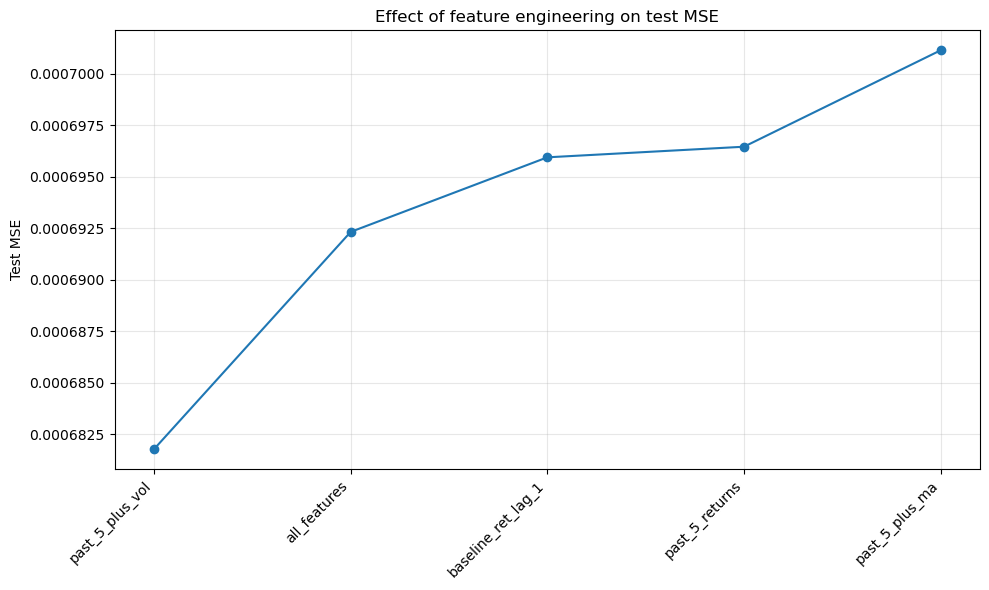

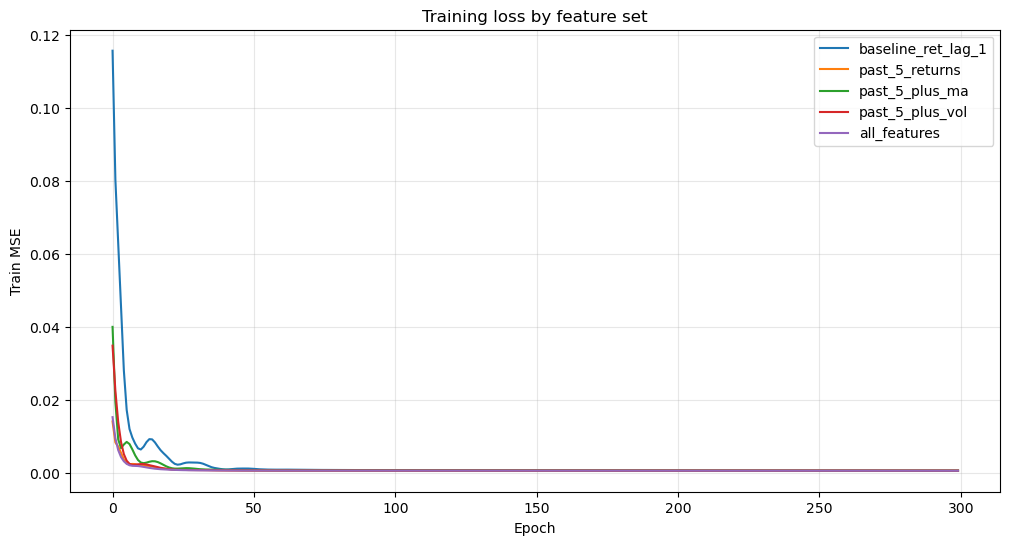

In [17]:

# Plot comparison table and training curves
display(results_df)

plt.figure(figsize=(10, 6))
plt.plot(results_df["feature_set"], results_df["mse"], marker="o")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Test MSE")
plt.title("Effect of feature engineering on test MSE")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
for name, out in results.items():
    plt.plot(out["train_losses"], label=name)
plt.xlabel("Epoch")
plt.ylabel("Train MSE")
plt.title("Training loss by feature set")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Best feature set: past_5_plus_vol
['ret_lag_1', 'ret_lag_2', 'ret_lag_3', 'ret_lag_4', 'ret_lag_5', 'vol_5']
{'mse': 0.0006817750982008874, 'mae': 0.017446845769882202, 'directional_accuracy': 0.5118437118437118}


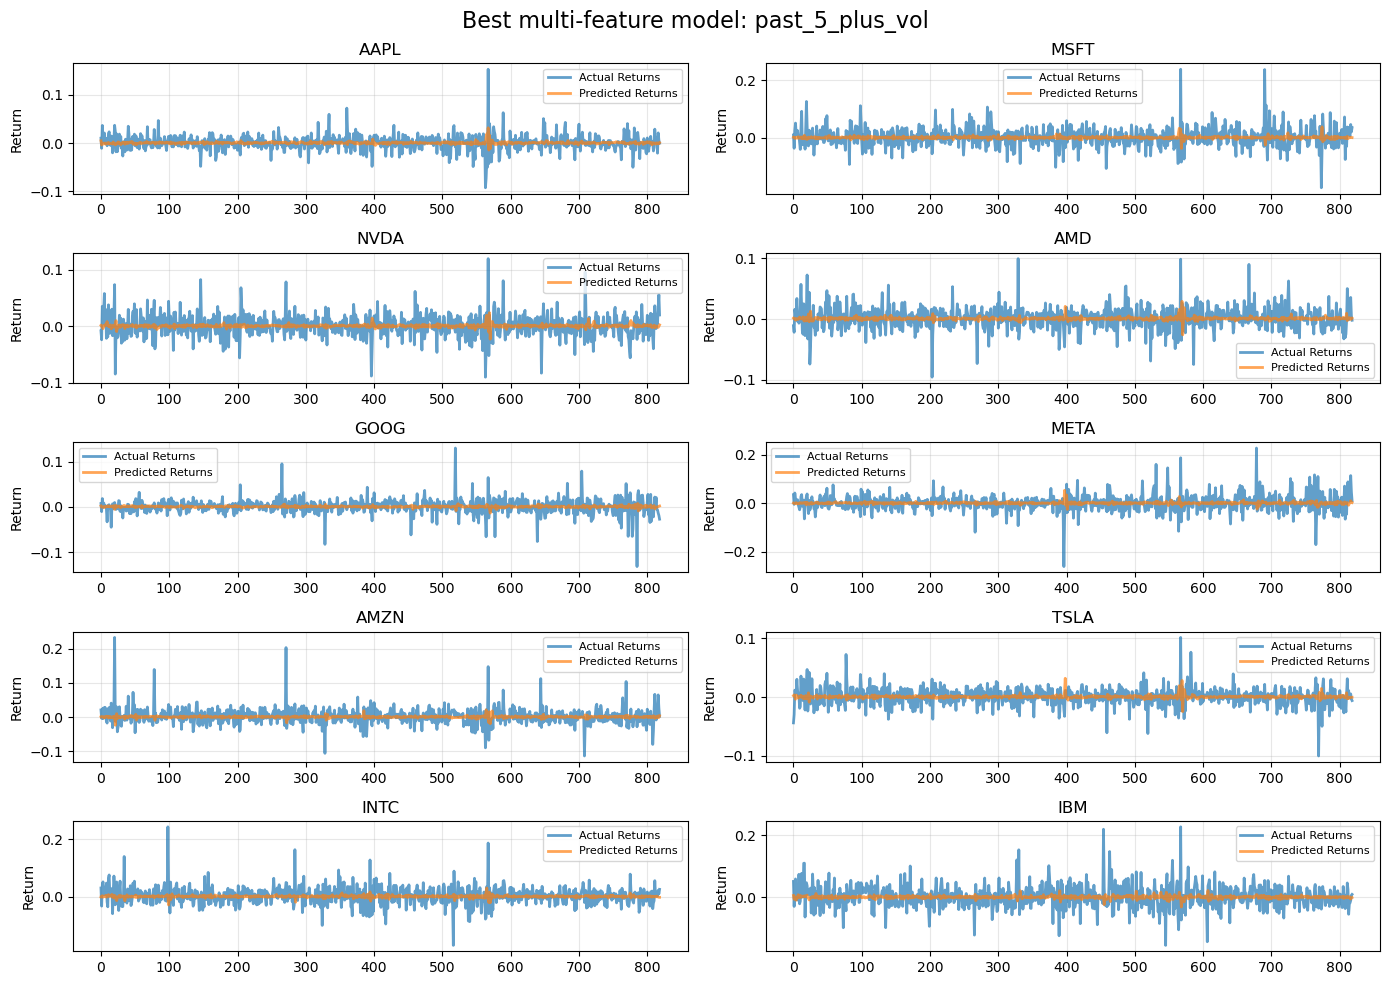

In [18]:

# Example: inspect best model predictions stock-by-stock
best_name = results_df.iloc[0]["feature_set"]
best_out = results[best_name]

print(f"Best feature set: {best_name}")
print(best_out["selected_features"])
print(best_out["metrics"])

plt.figure(figsize=(14, 10))
plt.suptitle(f"Best multi-feature model: {best_name}", fontsize=16)

best_pred = best_out["test_pred"].detach().cpu().numpy()
best_true = best_out["y_test"].detach().cpu().numpy()

for i, ticker in enumerate(tickers):
    plt.subplot(5, 2, i + 1)
    plt.plot(best_true[:, i], label="Actual Returns", linewidth=2, alpha=0.7)
    plt.plot(best_pred[:, i], label="Predicted Returns", linewidth=2, alpha=0.7)
    plt.title(ticker)
    plt.ylabel("Return")
    plt.grid(alpha=0.3)
    plt.legend(fontsize=8)

plt.tight_layout()
plt.show()


In [19]:

# Optional: direct deltas relative to the simplest baseline
baseline_mse = results["baseline_ret_lag_1"]["metrics"]["mse"]
baseline_mae = results["baseline_ret_lag_1"]["metrics"]["mae"]
baseline_dir = results["baseline_ret_lag_1"]["metrics"]["directional_accuracy"]

delta_df = results_df.copy()
delta_df["mse_change_vs_baseline"] = delta_df["mse"] - baseline_mse
delta_df["mae_change_vs_baseline"] = delta_df["mae"] - baseline_mae
delta_df["dir_acc_change_vs_baseline"] = delta_df["directional_accuracy"] - baseline_dir

print(delta_df.sort_values("mse_change_vs_baseline"))
display(delta_df.sort_values("mse_change_vs_baseline"))


          feature_set  num_features       mse       mae  directional_accuracy  \
0     past_5_plus_vol             6  0.000682  0.017447              0.511844   
1        all_features            10  0.000692  0.017642              0.508059   
2  baseline_ret_lag_1             1  0.000696  0.017700              0.496093   
3      past_5_returns             5  0.000696  0.017683              0.496581   
4      past_5_plus_ma             7  0.000701  0.017746              0.494628   

   mse_change_vs_baseline  mae_change_vs_baseline  dir_acc_change_vs_baseline  
0           -1.417607e-05               -0.000253                    0.015751  
1           -3.623543e-06               -0.000058                    0.011966  
2            0.000000e+00                0.000000                    0.000000  
3            5.147886e-07               -0.000017                    0.000488  
4            5.198701e-06                0.000046                   -0.001465  


,feature_set,num_features,mse,mae,directional_accuracy,mse_change_vs_baseline,mae_change_vs_baseline,dir_acc_change_vs_baseline
0,past_5_plus_vol,6,0.000682,0.017447,0.511844,-1.417607e-05,-0.000253,0.015751
1,all_features,10,0.000692,0.017642,0.508059,-3.623543e-06,-0.000058,0.011966
2,baseline_ret_lag_1,1,0.000696,0.017700,0.496093,0.000000e+00,0.000000,0.000000
3,past_5_returns,5,0.000696,0.017683,0.496581,5.147886e-07,-0.000017,0.000488
4,past_5_plus_ma,7,0.000701,0.017746,0.494628,5.198701e-06,0.000046,-0.001465
